In [1]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}



/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:

# --- INIT ---


# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'transformed_X_outlier_variance'
cluster_resolution = 0.05

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)


# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_5' % head_folder




In [3]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [5]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

# descriptions = list(adata.obs['description'].unique())
# clusters = list(adata.obs['cluster'].unique())

clusters = [0, 1, 2, 3]
cluster_cell_type_dict = dict(zip(clusters,['SMC','Fibroblast','Endothelial', 'Macrophage']))

descriptions = ['male aligned bmal1-ko', 
                'male misaligned bmal1-control', 
                'female aligned bmal1-ko', 
                'female misaligned bmal1-control', 
                'male aligned bmal1-control', 
                'female aligned bmal1-control']

print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)





Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3]


In [6]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)

        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [7]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)




12111

In [8]:
# --- DEFINE FN TO LOAD PARAMS FROM PATH ---

def load_param_dfs_from_path(res_folder):
    gene_log_alpha_path = '%s/gene_log_alpha.tsv' % res_folder
    gene_log_beta_path = '%s/gene_log_beta.tsv' % res_folder
    gene_log_min_max_path = '%s/log_min_max.tsv' % res_folder
    gene_stat_path = '%s/de_novo_metrics.tsv' % res_folder
    gene_log_alpha_df = pd.read_table(gene_log_alpha_path,sep='\t',index_col='gene')
    gene_log_beta_df = pd.read_table(gene_log_beta_path,sep='\t',index_col='gene')
    gene_log_min_max_df = pd.read_table(gene_log_min_max_path,sep='\t',index_col='gene')
    gene_stat_df = pd.read_table(gene_stat_path,sep='\t',index_col='gene')
    return gene_log_alpha_df, gene_log_beta_df, gene_log_min_max_df,gene_stat_df




In [279]:
# --- TEMP: SET THE CLUSTER --- 

cluster = 2
condit_1 = 'male aligned bmal1-control'
condit_2 = 'male misaligned bmal1-control'



In [280]:
gene_log_alpha_df1

,bin_0,bin_1,bin_2,bin_3
gene,,,,
0610009B22Rik,1.091855,1.621639,1.372051,1.509955
0610009E02Rik,-0.249165,0.780466,0.604283,0.147253
0610009L18Rik,1.050512,1.255491,1.270804,0.498485
0610010F05Rik,0.988156,1.291566,1.704682,-0.347024
0610010K14Rik,1.682547,2.355854,2.224114,2.050243
...,...,...,...,...
mt-Nd3,2.163068,2.738328,2.582231,2.709389
mt-Nd4,2.755213,2.865111,2.714376,2.569619
mt-Nd4l,2.328335,2.657067,2.621289,2.666558


In [281]:
# --- LOAD PARAMS ---

# ** load the parameters **
gene_log_alpha_df1, gene_log_beta_df1, gene_log_min_max_df1, gene_stat_df1 = load_param_dfs_from_path(cluster_description_folder_out_dict[cluster][condit_1])
gene_log_alpha_df2, gene_log_beta_df2, gene_log_min_max_df2, gene_stat_df2 = load_param_dfs_from_path(cluster_description_folder_out_dict[cluster][condit_2])

# ** get the overlap in gene names and restrict **
common_genes = sorted(list(set(gene_log_alpha_df1.index).intersection(set(gene_log_alpha_df2.index))))
gene_log_alpha_df1, gene_log_beta_df1, gene_log_min_max_df1, gene_stat_df1 = gene_log_alpha_df1.loc[common_genes], gene_log_beta_df1.loc[common_genes], gene_log_min_max_df1.loc[common_genes], gene_stat_df1.loc[common_genes]
gene_log_alpha_df2, gene_log_beta_df2, gene_log_min_max_df2, gene_stat_df2 = gene_log_alpha_df2.loc[common_genes], gene_log_beta_df2.loc[common_genes], gene_log_min_max_df2.loc[common_genes], gene_stat_df2.loc[common_genes]

# ** turn into Tensors **

# condit 1
gene_log_min1 = torch.Tensor(np.array(gene_log_min_max_df1['log_min'])) 
gene_log_max1 = torch.Tensor(np.array(gene_log_min_max_df1['log_max']))
gene_log_alpha1 = torch.Tensor(np.array(gene_log_alpha_df1).T)
gene_log_beta1 = torch.Tensor(np.array(gene_log_beta_df1).T)

# condit 2
gene_log_min2 = torch.Tensor(np.array(gene_log_min_max_df2['log_min'])) 
gene_log_max2 = torch.Tensor(np.array(gene_log_min_max_df2['log_max']))
gene_log_alpha2 = torch.Tensor(np.array(gene_log_alpha_df2).T)
gene_log_beta2 = torch.Tensor(np.array(gene_log_beta_df2).T)





In [282]:
# --- LOAD THE ADATAS ---

condit_1_adata = adata[(adata.obs['description'] == condit_1) & (adata.obs['cluster'] == cluster)]
condit_1_adata = condit_1_adata[:,common_genes]
condit_2_adata = adata[(adata.obs['description'] == condit_2) & (adata.obs['cluster'] == cluster)]
condit_2_adata = condit_2_adata[:,common_genes]
phases_sampled = torch.Tensor(np.array((condit_1_adata.obs['zt'] / 12.0) * np.pi)).unsqueeze(1)




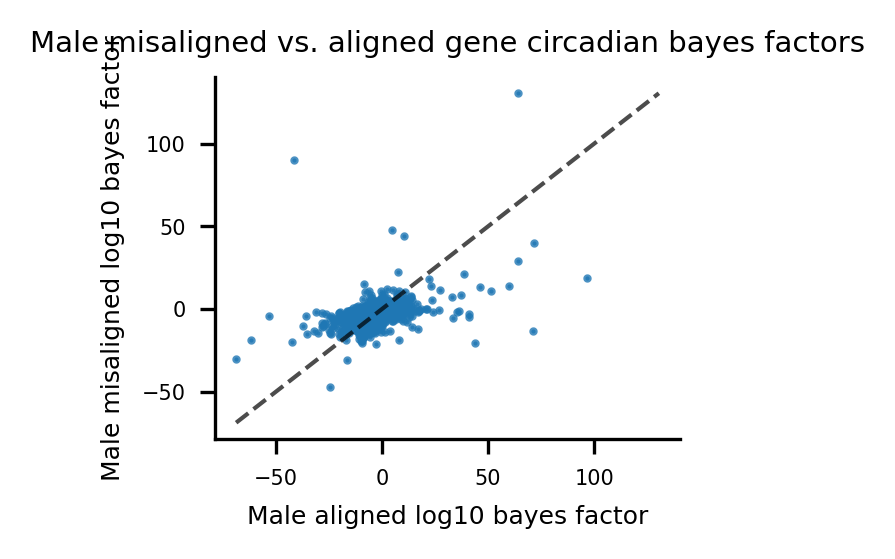

In [283]:


# --- VIZ THE RELATIONSHIP BETWEEN CIRCADIAN BF'S ---

min_val = min(np.min(gene_stat_df1['waveform_over_circadian_component_subtracted_log10_bf']), np.min(gene_stat_df2['waveform_over_circadian_component_subtracted_log10_bf']))
max_val = max(np.max(gene_stat_df1['waveform_over_circadian_component_subtracted_log10_bf']), np.max(gene_stat_df2['waveform_over_circadian_component_subtracted_log10_bf']))

fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.scatter(gene_stat_df1['waveform_over_circadian_component_subtracted_log10_bf'],gene_stat_df2['waveform_over_circadian_component_subtracted_log10_bf'],s=1,alpha=0.8)
plt.plot(np.linspace(min_val,max_val,1000),np.linspace(min_val,max_val,1000),c='k',alpha=0.7,linestyle='--')
plt.xlabel("Male aligned log10 bayes factor")
plt.ylabel("Male misaligned log10 bayes factor")
subfolder_out = '%s/misaligned_vs_aligned_bayes_factor_fig' % folder_out
if not os.path.exists(subfolder_out):
    os.makedirs(subfolder_out)
fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
plt.savefig(fileout,bbox_inches='tight')
plt.title("Male misaligned vs. aligned gene circadian bayes factors")
plt.show()

















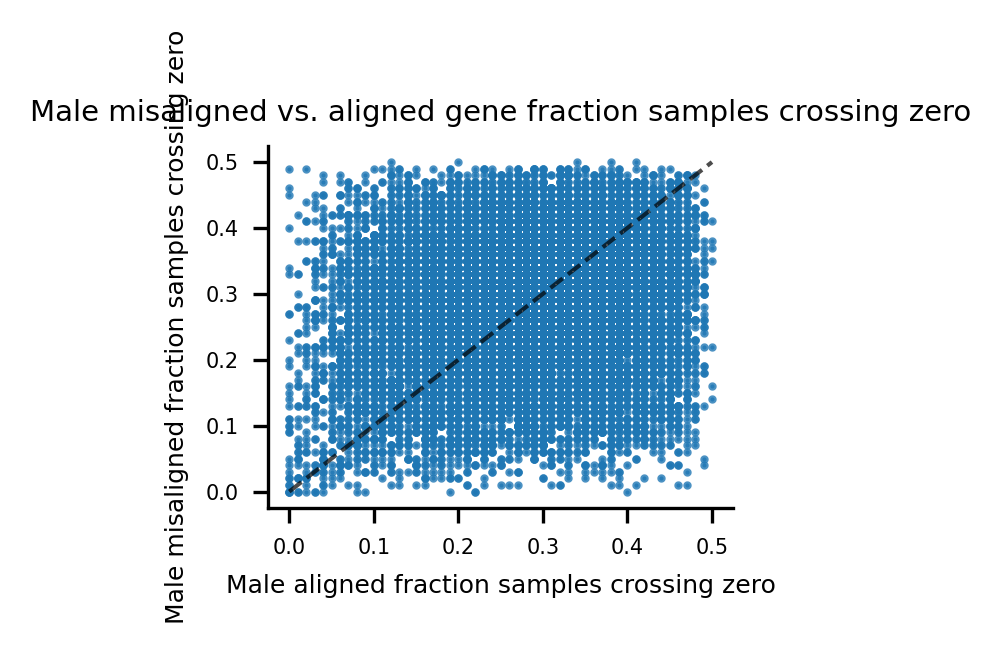

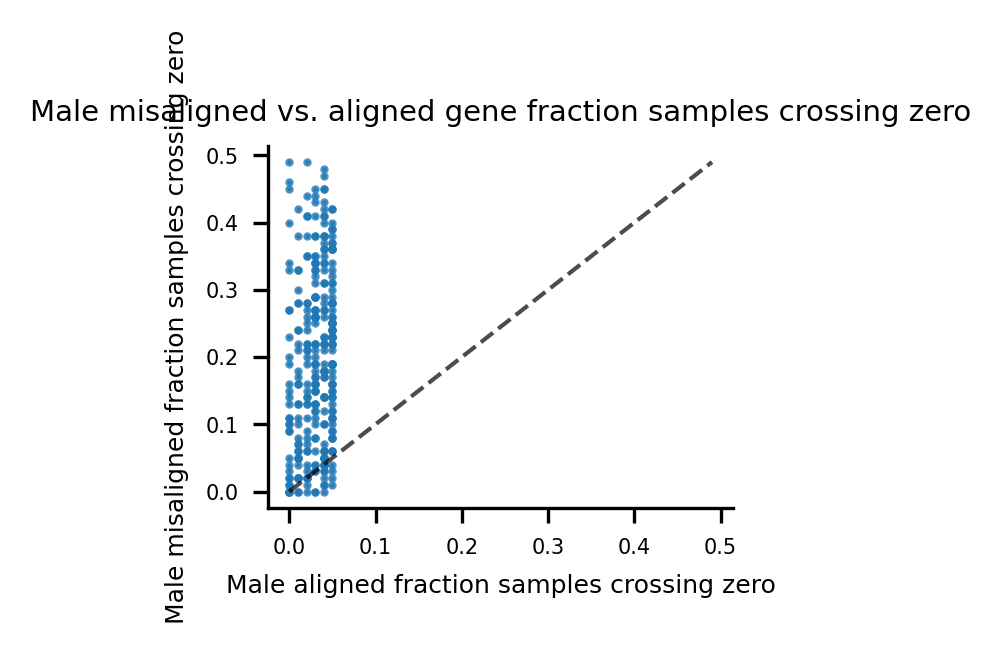

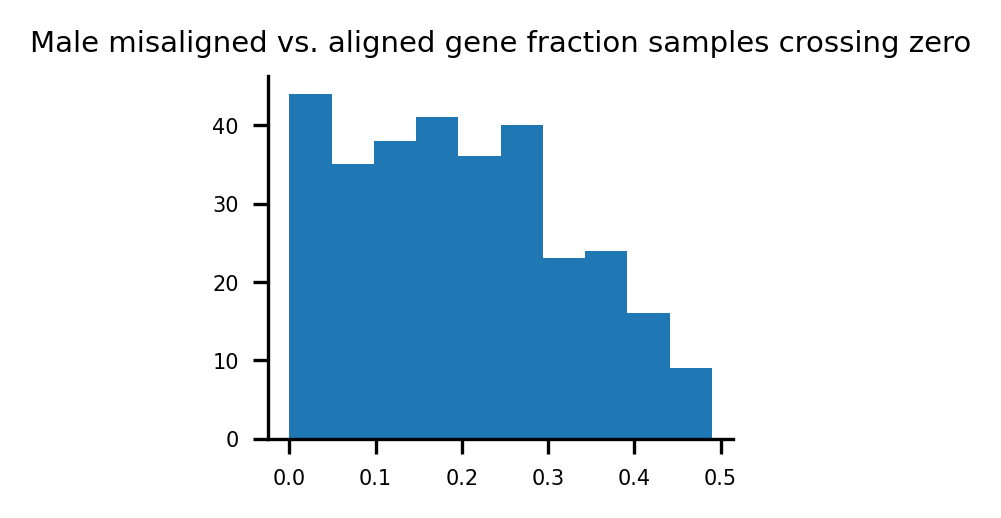

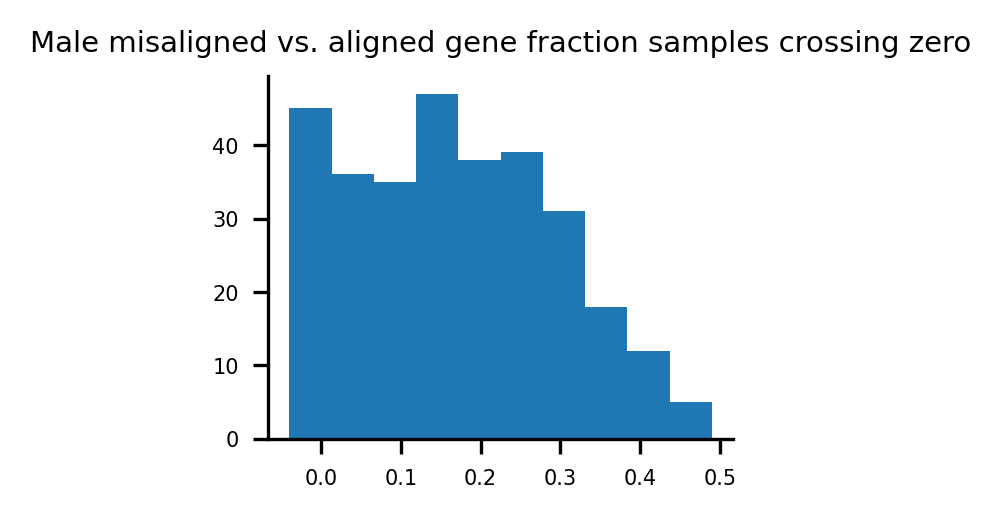

In [284]:
# --- VIZ THE RELATIONSHIP BETWEEN THE FRACTION OF SAMPLES CROSSING ZERO ---


min_val = min(np.min(gene_stat_df1['frac_circadian_samples_crossing_zero']), np.min(gene_stat_df2['frac_circadian_samples_crossing_zero']))
max_val = max(np.max(gene_stat_df1['frac_circadian_samples_crossing_zero']), np.max(gene_stat_df2['frac_circadian_samples_crossing_zero']))

fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.scatter(gene_stat_df1['frac_circadian_samples_crossing_zero'],gene_stat_df2['frac_circadian_samples_crossing_zero'],s=1,alpha=0.8)
plt.plot(np.linspace(min_val,max_val,1000),np.linspace(min_val,max_val,1000),c='k',alpha=0.7,linestyle='--')
plt.xlabel("Male aligned fraction samples crossing zero")
plt.ylabel("Male misaligned fraction samples crossing zero")
subfolder_out = '%s/misaligned_vs_aligned_fraction_samples_crossing_zero_fig' % folder_out
if not os.path.exists(subfolder_out):
    os.makedirs(subfolder_out)
fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
plt.savefig(fileout,bbox_inches='tight')
plt.title("Male misaligned vs. aligned gene fraction samples crossing zero")
plt.show()



cycling_in_aligned_genes = gene_stat_df1[gene_stat_df1['frac_circadian_samples_crossing_zero'] <= 0.05].index

min_val = min(np.min(gene_stat_df1['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes]), np.min(gene_stat_df2['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes]))
max_val = max(np.max(gene_stat_df1['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes]), np.max(gene_stat_df2['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes]))

fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.scatter(gene_stat_df1['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes],gene_stat_df2['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes],s=1,alpha=0.8)
plt.plot(np.linspace(min_val,max_val,1000),np.linspace(min_val,max_val,1000),c='k',alpha=0.7,linestyle='--')
plt.xlabel("Male aligned fraction samples crossing zero")
plt.ylabel("Male misaligned fraction samples crossing zero")
# subfolder_out = '%s/misaligned_vs_aligned_fraction_samples_crossing_zero_fig' % folder_out
# if not os.path.exists(subfolder_out):
#     os.makedirs(subfolder_out)
# fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
# plt.savefig(fileout,bbox_inches='tight')
plt.title("Male misaligned vs. aligned gene fraction samples crossing zero")
plt.show()



fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(gene_stat_df2['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes])
# plt.plot(np.linspace(min_val,max_val,1000),np.linspace(min_val,max_val,1000),c='k',alpha=0.7,linestyle='--')
# plt.xlabel("Male aligned fraction samples crossing zero")
# plt.ylabel("Male misaligned fraction samples crossing zero")
# subfolder_out = '%s/misaligned_vs_aligned_fraction_samples_crossing_zero_fig' % folder_out
# if not os.path.exists(subfolder_out):
#     os.makedirs(subfolder_out)
# fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
# plt.savefig(fileout,bbox_inches='tight')
plt.title("Male misaligned vs. aligned gene fraction samples crossing zero")
plt.show()



fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(gene_stat_df2['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes] - gene_stat_df1['frac_circadian_samples_crossing_zero'].loc[cycling_in_aligned_genes])
# plt.plot(np.linspace(min_val,max_val,1000),np.linspace(min_val,max_val,1000),c='k',alpha=0.7,linestyle='--')
# plt.xlabel("Male aligned fraction samples crossing zero")
# plt.ylabel("Male misaligned fraction samples crossing zero")
# subfolder_out = '%s/misaligned_vs_aligned_fraction_samples_crossing_zero_fig' % folder_out
# if not os.path.exists(subfolder_out):
#     os.makedirs(subfolder_out)
# fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
# plt.savefig(fileout,bbox_inches='tight')
plt.title("Male misaligned vs. aligned gene fraction samples crossing zero")
plt.show()





In [285]:
# --- DEFINE FUNCTION TO GET THE FFT SAMPLES ---

def get_log_prop_samples_and_fft(cluster,description,num_grid_points,num_samples,gene_list=None):
    
    # ** load metric df **
    metric_path = '%s/de_novo_metrics.tsv' % cluster_description_folder_out_dict[cluster][description]
    metric_df = pd.read_table(metric_path,index_col='gene',sep='\t')

    # ** load gene parameters **
    gene_log_alpha_path = '%s/gene_log_alpha.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_beta_path = '%s/gene_log_beta.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_min_max_path = '%s/log_min_max.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_alpha_df = pd.read_table(gene_log_alpha_path,sep='\t',index_col='gene')
    gene_log_beta_df = pd.read_table(gene_log_beta_path,sep='\t',index_col='gene')
    gene_log_min_max_df = pd.read_table(gene_log_min_max_path,sep='\t',index_col='gene')
    if gene_list is not None:
        gene_log_alpha_df = gene_log_alpha_df.loc[gene_list]
        gene_log_beta_df = gene_log_beta_df.loc[gene_list]
        gene_log_min_max_df = gene_log_min_max_df.loc[gene_list]
    gene_log_min = torch.Tensor(np.array(gene_log_min_max_df['log_min'])) 
    gene_log_max = torch.Tensor(np.array(gene_log_min_max_df['log_max'])) 
    
    
    # ** get the log_prop_dist obj **
    log_prop_dist = torch.distributions.beta.Beta(torch.Tensor(np.exp(np.array(gene_log_alpha_df)).T), torch.Tensor(np.exp(np.array(gene_log_beta_df))).T)

    # ** sample the waveforms **
    sampled_log_prop = log_prop_dist.sample((num_samples,)) # [num_samples x num_time_points x num_genes]
    sampled_log_prop = (sampled_log_prop * (gene_log_max.unsqueeze(0).unsqueeze(0) - gene_log_min.unsqueeze(0).unsqueeze(0))) + gene_log_min.unsqueeze(0).unsqueeze(0)

    # ** compute the sampled fft **
    fft_res = np.fft.fft(sampled_log_prop,axis=1)
    
    return sampled_log_prop, fft_res


# --- GET SAMPLED WAVEFORMS AND FFT'S FOR M AND F ---

num_grid_points = 4
num_samples = 300

sampled_log_prop_1, fft_res_1 = get_log_prop_samples_and_fft(cluster,condit_1,num_grid_points,num_samples,gene_list=common_genes)
sampled_log_prop_2, fft_res_2 = get_log_prop_samples_and_fft(cluster,condit_2,num_grid_points,num_samples,gene_list=common_genes)

# ** compute the sampled fft **
fft_res = np.fft.fft(sampled_log_prop_1,axis=1)
freqs = np.fft.fftfreq(num_grid_points,d=24.0/num_grid_points)
periods = 1 / freqs
amps = abs(fft_res)
circadian_index = np.where(np.isin(periods,[24]))[0]






/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_65634/3475691983.py:48: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs


In [286]:
# --- FIND GENES FOR WHICH THERE IS A DIFFERENCE AT LEAST ONE TIME POINT ---

confidence = 90
dif_sampled_log_prop = sampled_log_prop_2 - sampled_log_prop_1
high_dif_sampled_log_prop = np.percentile(dif_sampled_log_prop,100 - ((100 - confidence) / 2),axis=0)
low_dif_sampled_log_prop = np.percentile(dif_sampled_log_prop,((100 - confidence) / 2),axis=0)
bool_passes = 1 - np.min(((0 <= high_dif_sampled_log_prop) & (0 >= low_dif_sampled_log_prop)).astype(int),axis=0)
de_gene_indices = np.where(bool_passes)[0]
avg_waveform_change = torch.mean(dif_sampled_log_prop[:,:,de_gene_indices],dim=0).T # [num_genes x num_times]
de_genes = np.array(common_genes)[de_gene_indices]


In [287]:
# # --- WRITE OUT THE DIFFERENTIALLY EXPRESSED GENES ---


# subfolder_out = '%s/de_genes' % folder_out
# if not os.path.exists(subfolder_out):
#     os.makedirs(subfolder_out)
# fileout = '%s/cluster_%s.txt' % (subfolder_out,cluster_cell_type_dict[cluster])
# with open(fileout,'wb') as file_obj:
#     file_obj.write("\n".join(list(de_genes)).encode())


In [288]:
# --- GET THE MESOR SAMPLES AND DETECT GENES W/ DIFFERENT MESORS ---


# get mesor samples
log10_mesor_samples_1 = torch.mean(sampled_log_prop_1,dim=1).numpy() / np.log(10)
log10_mesor_samples_2 = torch.mean(sampled_log_prop_2,dim=1).numpy() / np.log(10)

# compute the fraction greater / smaller in condit 2
frac_mesor_samples_larger = np.mean(log10_mesor_samples_2 > log10_mesor_samples_1,axis=0)

# compute the effect size
mesor_effect = np.mean(log10_mesor_samples_2,axis=0) - np.mean(log10_mesor_samples_1,axis=0)

# add to adata
condit_2_adata.var['frac_mesor_samples_larger'] = frac_mesor_samples_larger
condit_2_adata.var['mesor_effect_size'] = mesor_effect






/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_65634/3340537355.py:15: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  condit_2_adata.var['frac_mesor_samples_larger'] = frac_mesor_samples_larger


In [289]:
# --- ASSESS DE AMPLITUDE ---

# get amp samples
amp_samples_1 = abs(fft_res_1)[:,circadian_index.item(),:]
amp_samples_2 = abs(fft_res_2)[:,circadian_index.item(),:]

# compute the fraction greater in condit 2
frac_amp_samples_larger = np.mean(amp_samples_2 > amp_samples_1,axis=0)

# compute the effect size
amp_effect = np.mean((amp_samples_2 - amp_samples_1),axis=0) / np.log(10)

# add to adata
condit_2_adata.var['frac_amp_samples_larger'] = frac_amp_samples_larger
condit_2_adata.var['amp_effect_size'] = amp_effect



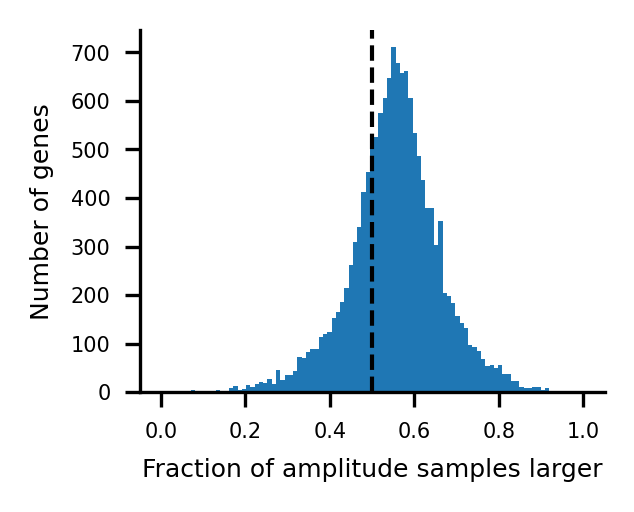

/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_65634/3440034718.py:27: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  plt.hist(condit_2_adata.var['frac_amp_samples_larger'].loc[inter_genes],bins=np.linspace(0,1,50))


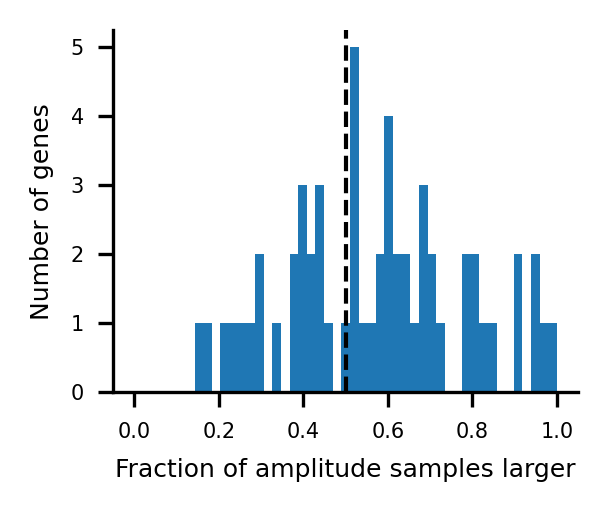

In [290]:
# # --- LOOK TO SEE IF THE AMPLITUDES ARE SHIFTED IN MISALIGNED ---

fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(condit_2_adata.var['frac_amp_samples_larger'],bins=np.linspace(0,1,100))
plt.xlabel("Fraction of amplitude samples larger")
plt.ylabel("Number of genes")
plt.axvline(x = 0.5,c='k',linestyle='--')
subfolder_out = '%s/misaligned_amp_frac_greater_dist_figs' % folder_out
if not os.path.exists(subfolder_out):
    os.makedirs(subfolder_out)
fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
plt.savefig(fileout,bbox_inches='tight')
plt.show()





a = gene_stat_df1[gene_stat_df1['waveform_over_circadian_component_subtracted_log10_bf'] >= 2]
b = gene_stat_df2[gene_stat_df2['waveform_over_circadian_component_subtracted_log10_bf'] >= 2]
union_genes = set(a.index).union(set(b.index))
inter_genes = set(a.index).intersection(set(b.index))

fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(condit_2_adata.var['frac_amp_samples_larger'].loc[inter_genes],bins=np.linspace(0,1,50))
plt.xlabel("Fraction of amplitude samples larger")
plt.ylabel("Number of genes")
plt.axvline(x = 0.5,c='k',linestyle='--')
subfolder_out = '%s/misaligned_mutual_cyclers_amp_frac_greater_dist_figs' % folder_out
if not os.path.exists(subfolder_out):
    os.makedirs(subfolder_out)
fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
plt.savefig(fileout,bbox_inches='tight')
plt.show()


In [291]:
# --- GET THE DE GENE SETS ---


# increased amplitude
increased_amplitude_genes = set(condit_2_adata[:,condit_2_adata.var['frac_amp_samples_larger'] >= 0.8].var_names)
increased_amplitude_genes = increased_amplitude_genes.intersection(set(de_genes))
increased_amplitude_genes = increased_amplitude_genes.intersection(set(gene_stat_df2[gene_stat_df2['frac_circadian_samples_crossing_zero'] <= 0.05].index))
increased_amplitude_genes = sorted(list(increased_amplitude_genes))

# decreased amp
decreased_amplitude_genes = set(condit_2_adata[:,condit_2_adata.var['frac_amp_samples_larger'] <= 0.2].var_names)
decreased_amplitude_genes = decreased_amplitude_genes.intersection(set(de_genes))
decreased_amplitude_genes = decreased_amplitude_genes.intersection(set(gene_stat_df1[gene_stat_df1['frac_circadian_samples_crossing_zero'] <= 0.05].index))
decreased_amplitude_genes = sorted(list(decreased_amplitude_genes))


# increased mesor
increased_mesor_genes = set(condit_2_adata[:,condit_2_adata.var['frac_mesor_samples_larger'] >= 0.8].var_names)
increased_mesor_genes = increased_mesor_genes.intersection(set(de_genes))
increased_mesor_genes = sorted(list(increased_mesor_genes))


# decreased mesor
decreased_mesor_genes = set(condit_2_adata[:,condit_2_adata.var['frac_mesor_samples_larger'] <= 0.2].var_names)
decreased_mesor_genes = decreased_mesor_genes.intersection(set(de_genes))
decreased_mesor_genes = sorted(list(decreased_mesor_genes))







In [292]:
# --- SET THE GENE ENRICHMENT SETS ---

import gseapy
enrichment_gene_sets = ['GO_Biological_Process_2018','KEGG_2016', 'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X']



In [293]:
# --- LOOK AT PATHWAY ENRICHMENT FOR THE DE GENE SETS ---


de_gene_set_list = [increased_amplitude_genes,decreased_amplitude_genes,increased_mesor_genes,decreased_mesor_genes]
de_gene_set_name_list = ['increased_amplitude','decreased_amplitude','increased_mesor','decreased_mesor']

for de_gene_set,de_gene_set_name in zip(de_gene_set_list,de_gene_set_name_list):
    for enrichment_gene_set in enrichment_gene_sets:


        # get enrichment results
        res = gseapy.enrichr(gene_list=de_gene_set,
                             gene_sets = enrichment_gene_set,
                            organism = 'mouse',
                            background=list(reg_genes_to_est))


        # get the DF
        res_df = res.results
        res_df = res_df.set_index("Gene_set")

        # make the subfolder
        subfolder_out = '%s/%s_enrichment/%s' % (folder_out,de_gene_set_name,enrichment_gene_set)
        if not os.path.exists(subfolder_out):
            os.makedirs(subfolder_out)
        fileout = '%s/cluster_%s_enrichment.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
        res_df.to_csv(fileout,sep='\t')

    
    


KeyboardInterrupt: 

In [209]:
# # --- ACROPHASE DE ---

# female_acrophase_samples = (np.arctan2(female_fft_res[:,circadian_index.item(),:].imag,female_fft_res[:,circadian_index.item(),:].real) % (2 * np.pi))
# male_acrophase_samples = (np.arctan2(male_fft_res[:,circadian_index.item(),:].imag,male_fft_res[:,circadian_index.item(),:].real) % (2 * np.pi))
# dif_acrophase_samples = female_acrophase_samples - male_acrophase_samples
# dif_acrophase_euclid_samples = np.zeros((dif_acrophase_samples.shape[0],dif_acrophase_samples.shape[1],2))
# dif_acrophase_euclid_samples[:,:,0] = np.cos(dif_acrophase_samples)
# dif_acrophase_euclid_samples[:,:,1] = np.sin(dif_acrophase_samples)





# # # samples are of shape: [num_samples x num_genes]
# # def compute_fraction_samples_crossing_zero(samples):
# #     frac_samples_above_zero = np.mean((samples > 0).astype(int),axis=0)
# #     above_50_indices = np.where(frac_samples_above_zero >= 0.5)[0]
# #     frac_samples_crossing_zero = frac_samples_above_zero.copy()
# #     frac_samples_crossing_zero[above_50_indices] = 1 - frac_samples_above_zero[above_50_indices]
# #     return frac_samples_crossing_zero



In [294]:
'Ccl2' in condit_1_adata.var_names



True

In [248]:
cluster_adata = adata[adata.obs['cluster'] == cluster]
cluster_adata

View of AnnData object with n_obs × n_vars = 2917 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [265]:
aligned_cluster_adata

View of AnnData object with n_obs × n_vars = 481 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [298]:
misaligned_props

[0.0, 0.0, 0.0, 1.7419054e-06]

In [274]:
cluster_adata

View of AnnData object with n_obs × n_vars = 2917 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [273]:
misaligned_cluster_adata

View of AnnData object with n_obs × n_vars = 230 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_65634/2556406108.py:19: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.arange(0,4,1),np.log10(np.array(aligned_props)),label='aligned',s=3)
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_65634/2556406108.py:20: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.arange(0,4,1),np.log10(np.array(misaligned_props)),label='misaligned',s=3)


Text(0.5, 1.0, 'Ccr2')

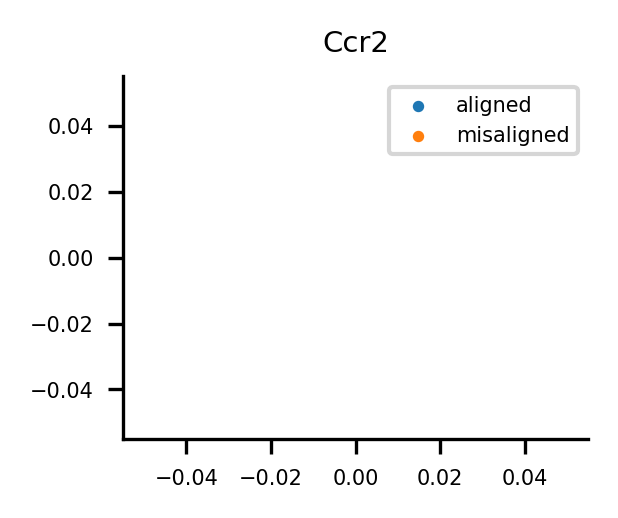

In [301]:
# --- VIZ THE PSEUDOBULK PROPS FOR GENE OF INTEREST ---

gene = 'Ccr2' # 'Ccr2' # decreased_amplitude_genes[0]
cluster_adata = adata[adata.obs['cluster'] == cluster]
aligned_cluster_adata = cluster_adata[cluster_adata.obs['description'] == 'female aligned bmal1-control']
misaligned_cluster_adata = cluster_adata[cluster_adata.obs['description'] == 'female misaligned bmal1-control']

aligned_props, misaligned_props = [], []
for zt in [0,6,12,18]:
    zt_aligned_adata = aligned_cluster_adata[aligned_cluster_adata.obs['zt'] == zt]
    zt_misaligned_adata = misaligned_cluster_adata[misaligned_cluster_adata.obs['zt'] == zt]
    aligned_prop = np.sum(zt_aligned_adata[:,gene].X) / np.sum(zt_aligned_adata.obs['lib_size'])
    misaligned_prop = np.sum(zt_misaligned_adata[:,gene].X) / np.sum(zt_misaligned_adata.obs['lib_size'])
    aligned_props.append(aligned_prop)
    misaligned_props.append(misaligned_prop)

    
fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
plt.scatter(np.arange(0,4,1),np.log10(np.array(aligned_props)),label='aligned',s=3)
plt.scatter(np.arange(0,4,1),np.log10(np.array(misaligned_props)),label='misaligned',s=3)
# plt.scatter(np.arange(0,4,1),np.log10(np.array(m_props)),label='aligned')
sns.despine()
plt.legend()
plt.title(gene)




In [246]:
condit_2_adata

AnnData object with n_obs × n_vars = 230 × 10960
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'frac_mesor_samples_larger', 'mesor_effect_size', 'frac_amp_samples_larger',

In [242]:
# --- VIZ THE PSEUDOBULK PROPS FOR GENE OF INTEREST ---

gene = 'Ccr2' # decreased_amplitude_genes[0]

f_props =[ ]
for zt in [0,6,12,18]:
    zt_adata = condit_2_adata[condit_2_adata.obs['zt'] == zt]
    prop = np.sum(zt_adata[:,gene].X) / np.sum(zt_adata.obs['lib_size'])
    f_props.append(prop)
m_props =[ ]
for zt in [0,6,12,18]:
    zt_adata = condit_1_adata[condit_1_adata.obs['zt'] == zt]
    prop = np.sum(zt_adata[:,gene].X) / np.sum(zt_adata.obs['lib_size'])
    m_props.append(prop)
    
    
plt.scatter(np.arange(0,4,1),np.log10(np.array(f_props)),label='misaligned')
plt.scatter(np.arange(0,4,1),np.log10(np.array(m_props)),label='aligned')
plt.legend()
plt.title(gene)



KeyError: 'Ccr2'

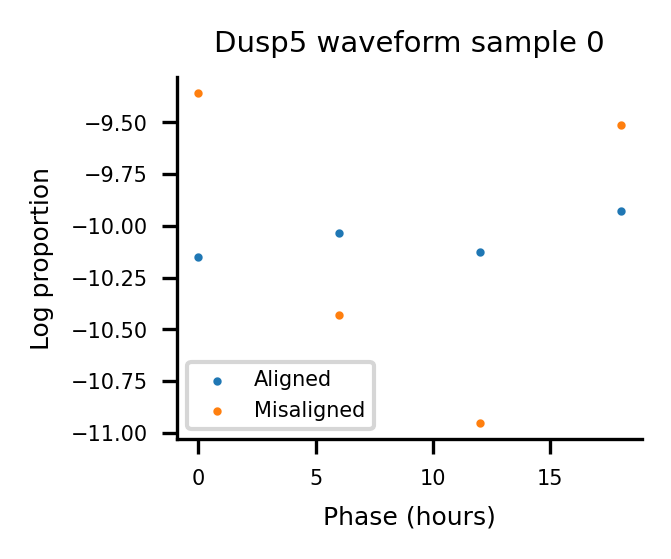

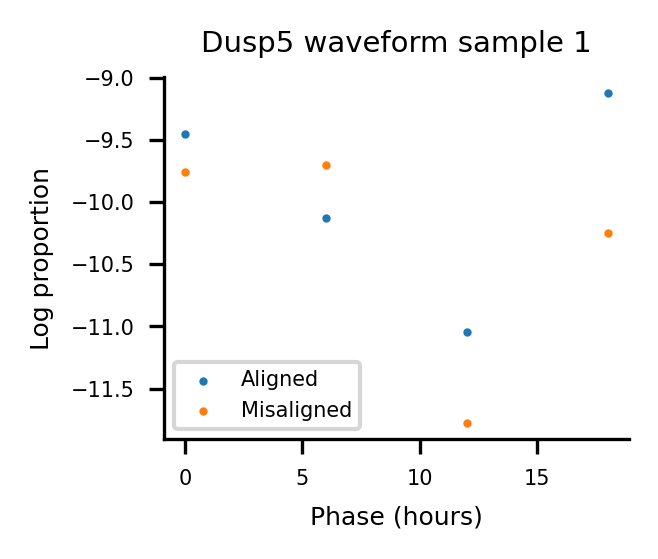

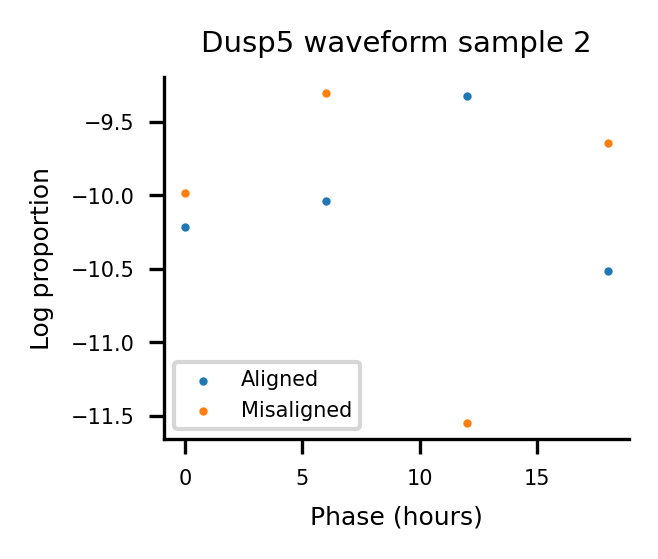

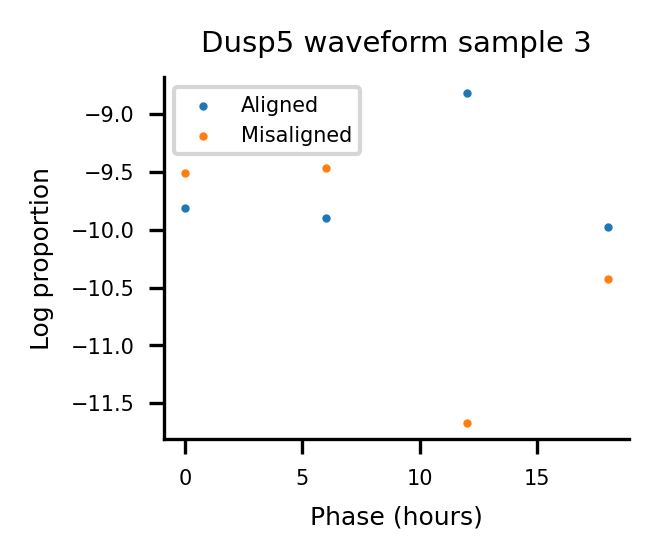

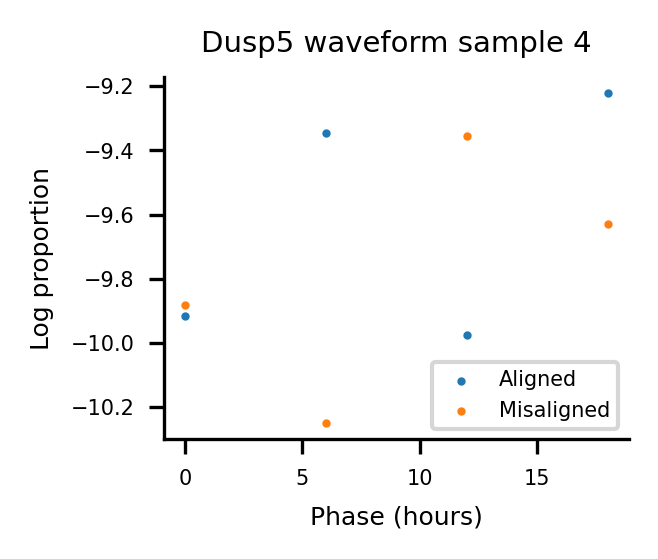

In [232]:
# --- VIZ WAVEFORMS ---

gene_of_interest = gene
gene_index = np.where(condit_2_adata.var_names == gene_of_interest)[0]

for sample in range(0,5):

    fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
    sns.despine()
    plt.scatter((np.arange(0,num_grid_points,1) / num_grid_points) * 24.0,sampled_log_prop_1[sample,:,gene_index].numpy(),s=1,label='Aligned')
    plt.scatter((np.arange(0,num_grid_points,1) / num_grid_points) * 24.0,sampled_log_prop_2[sample,:,gene_index].numpy(),s=1,label='Misaligned')
    plt.title("%s waveform sample %s" % (gene_of_interest,sample))
    plt.xlabel("Phase (hours)")
    plt.ylabel("Log proportion")
    plt.legend()
    plt.show()




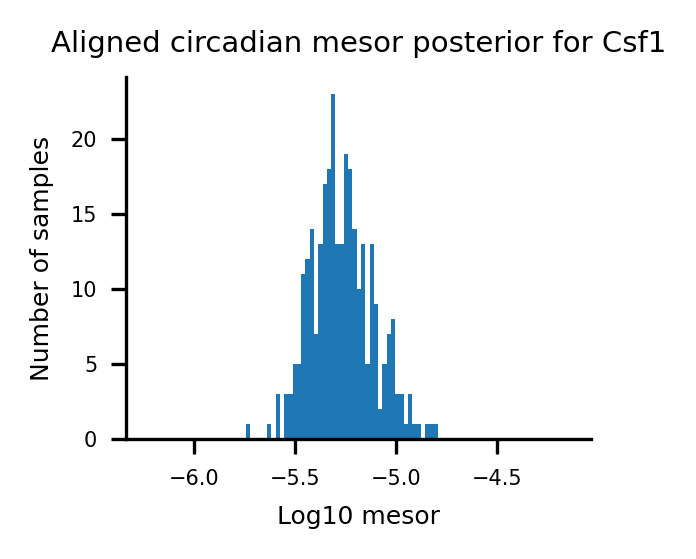

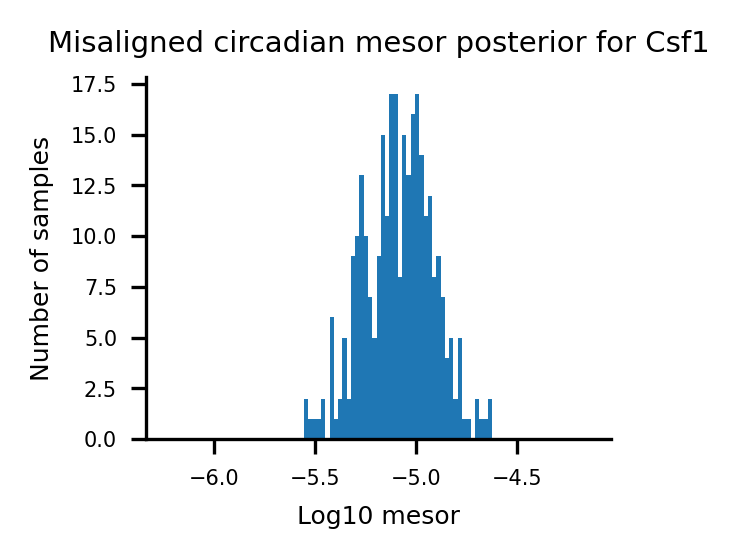

In [227]:
# --- VIZ THE MESOR DISTRIBUTIONS ---


log10_mesor_samples_1 = torch.mean(sampled_log_prop_1,dim=1)[:,gene_index].numpy().flatten() / np.log(10)
log10_mesor_samples_2 = torch.mean(sampled_log_prop_2,dim=1)[:,gene_index].numpy().flatten() / np.log(10)
min_val = min(np.min(log10_mesor_samples_1),np.min(log10_mesor_samples_2)) - 0.5
max_val = max(np.max(log10_mesor_samples_1),np.max(log10_mesor_samples_2)) + 0.5

fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(log10_mesor_samples_1,bins=np.linspace(min_val,max_val,100))
plt.xlabel("Log10 mesor")
plt.ylabel("Number of samples")
plt.title("Aligned circadian mesor posterior for %s" % gene_of_interest)
plt.show()



fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(log10_mesor_samples_2,bins=np.linspace(min_val,max_val,100))
plt.xlabel("Log10 mesor")
plt.ylabel("Number of samples")
plt.title("Misaligned circadian mesor posterior for %s" % gene_of_interest)
plt.show()



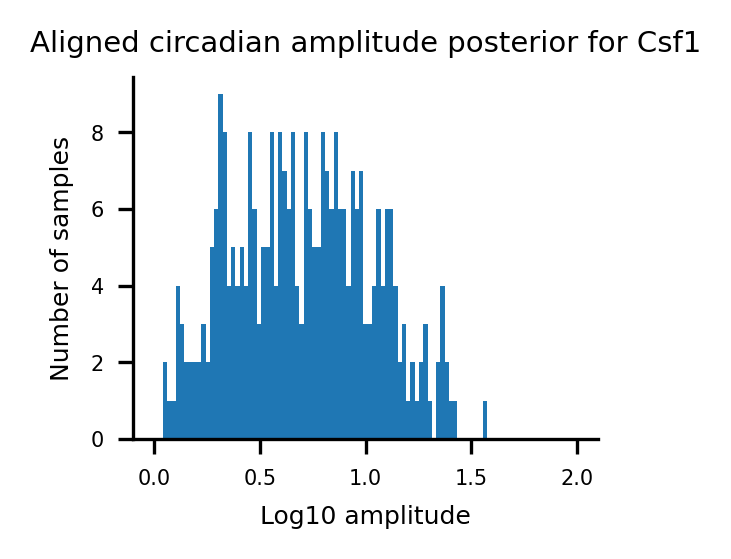

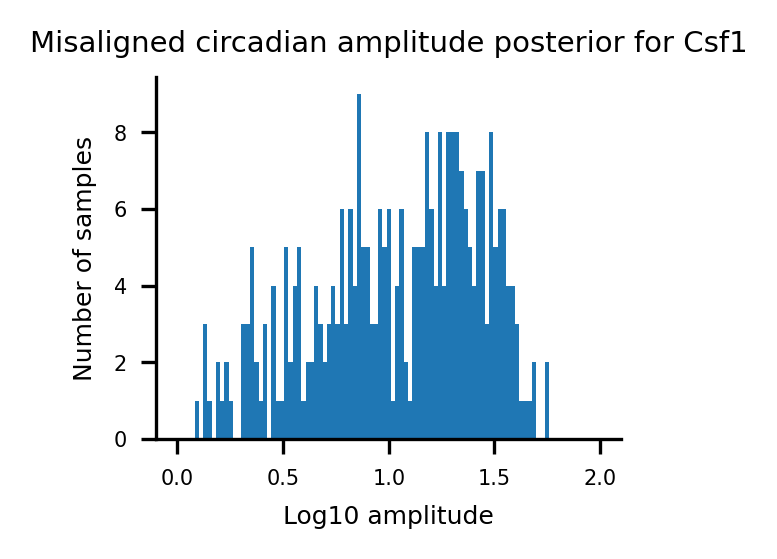

In [228]:
# --- VIZ AMP DISTRIBUTIONS ---

fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(abs(fft_res_1)[:,circadian_index,gene_index].flatten() / np.log(10),bins=np.linspace(0,2,100))
plt.xlabel("Log10 amplitude")
plt.ylabel("Number of samples")
plt.title("Aligned circadian amplitude posterior for %s" % gene_of_interest)
plt.show()


fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist(abs(fft_res_2)[:,circadian_index,gene_index].flatten() / np.log(10),bins=np.linspace(0,2,100))
plt.xlabel("Log10 amplitude")
plt.ylabel("Number of samples")
plt.title("Misaligned circadian amplitude posterior for %s" % gene_of_interest)
plt.show()




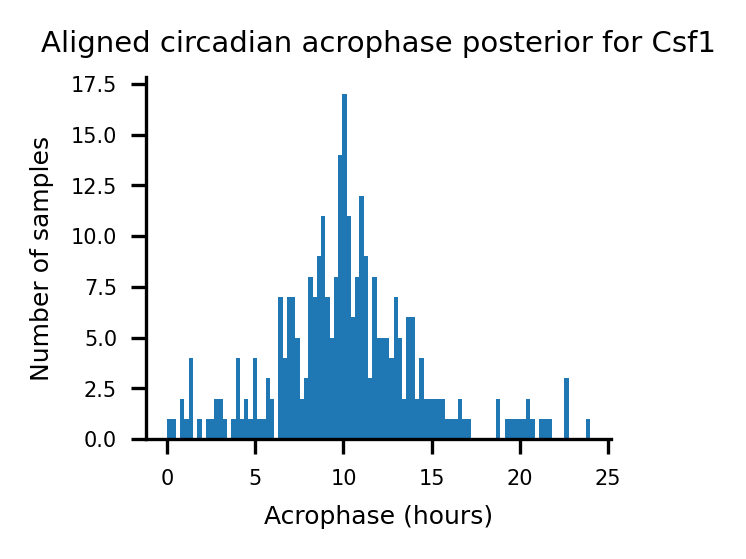

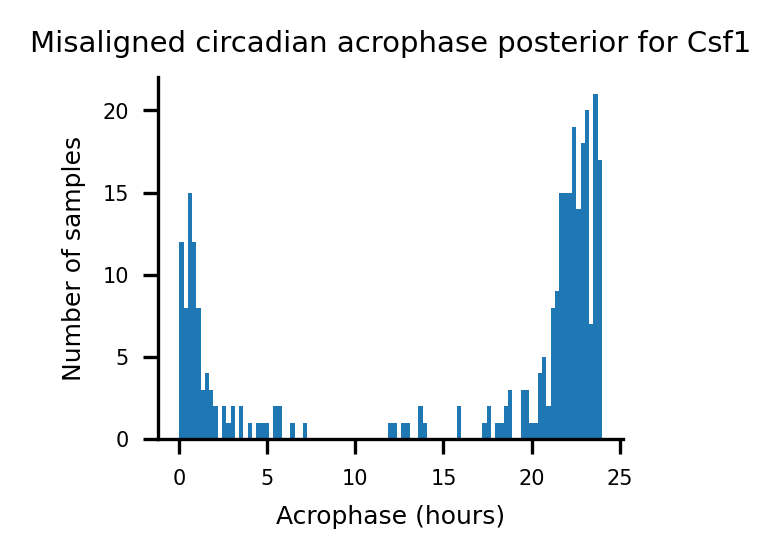

In [229]:
# --- VIZ ACROPHASE DISTRIBUTIONS ---


# get the female and male acrophase samples for the gene of interest
acro_samples_1 = np.arctan2(fft_res_1[:,circadian_index,gene_index].imag, fft_res_1[:,circadian_index,gene_index].real).flatten() % (2 * np.pi)
acro_samples_2 = np.arctan2(fft_res_2[:,circadian_index,gene_index].imag, fft_res_2[:,circadian_index,gene_index].real).flatten() % (2 * np.pi)


fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist((acro_samples_1 / np.pi) * 12.0,bins=np.linspace(0,24,100))
plt.xlabel("Acrophase (hours)")
plt.ylabel("Number of samples")
plt.title("Aligned circadian acrophase posterior for %s" % gene_of_interest)
plt.show()


fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
sns.despine()
plt.hist((acro_samples_2 / np.pi) * 12.0,bins=np.linspace(0,24,100))
plt.xlabel("Acrophase (hours)")
plt.ylabel("Number of samples")
plt.title("Misaligned circadian acrophase posterior for %s" % gene_of_interest)
plt.show()


